# Biquadratic Coupling Demo 2

Another demonstration with an out-of-plane hysteresis. But we are using 2 CoFe layers this time. It take quite a lot of time to run this demo because we are relaxing the system at each magnetic field step. Please be patient.

In the previous demo, we used a time-dependent external field to compute the hysteresis. However, in this demo, the saturation magnetization was lowered to a realistic value. The time-depedent field method would create a coercivity point in the loop in this case. Therefore, we are using this apporach of relaxing at each field step.

Implemented by Jed Cheng (jed.cheng@mag.ed.kyushu-u.ac.jp)

In [5]:
from magnumnp import *
import torch
from matplotlib import pyplot as plt
import numpy as np



%config InlineBackend.figure_format = 'retina'

torch.set_default_dtype(torch.float32)

In [20]:
sigma2 = np.array([0.0, -0.1, -0.05, -0.01])
sigma2 = sigma2 * 2


B_min = -5
B_max = 5
n_pts = 400
B_z = np.linspace(B_min, B_max, n_pts )
B_z2 = np.linspace(B_max, B_min, n_pts )

In [ ]:

for i, sigma2_ in enumerate(sigma2):
        Timer.enable()

        Mz = np.zeros(2*n_pts)
        Bz = np.zeros(2*n_pts)

        J_rkky = sigma2_

        # initialize mesh
        n  = (20, 20, 5)
        dx = (3e-9, 3e-9, 2e-9)
        mesh = Mesh(n, dx)
        state = State(mesh, device="cuda")

        state.material = {
                "alpha": 1
                }

        domain1 = state.zeros(n, dtype=torch.bool)
        domain2 = state.zeros(n, dtype=torch.bool)
        domain1[:,:,0:2] = True
        domain2[:,:,3:5] = True

        # Set initial magnetization
        state.m = state.Constant([0, 0, 0])
        size_ref = state.m[domain1].shape
        state.m[domain1] = state.Tensor([0.99, 0.01, 0])
        state.m[domain2] = state.Tensor([-0.99, -0.01, 0])


        Ku = state.Constant([0.0]) 
        Ku[domain1] = 3.7e3
        Ku[domain2] = 3.7e3


        A = state.Constant([0.0]) 
        A[domain1] = 15e-12
        A[domain2] = 15e-12


        Ms = state.Constant([0.0])
        Ms[domain1] = 1300e3
        Ms[domain2] = 1300e3

        Ku_axis = state.Constant([1, 0, 0])
        Ku_axis[domain1] = state.Tensor([1, 0, 0])
        Ku_axis[domain2] = state.Tensor([1, 0, 0])


        state.material['Ms'] = Ms
        state.material['A'] = A
        state.material['Ku'] = Ku
        state.material['Ku_axis'] = Ku_axis


        exchange = ExchangeField()
        rkky      = BiquadraticField(J_rkky, "z", 1, 3,)
        aniso     = UniaxialAnisotropyField()
        demag    = DemagField()


        for j, B in enumerate(B_z):
                external = ExternalField([0, 0, B/constants.mu_0])
                llg = LLGSolver([demag, exchange, aniso, external, rkky])
                llg.relax(state, silent=True, maxiter=100)                
                domain1_ = state.m[domain1].average()
                domain2_ = state.m[domain2].average()

                Mz_ = (domain1_[2].item() + domain2_[2].item())/2
                Mz[j] = Mz_

                if j % 50 == 0:
                        print(f"sigma2: {sigma2_}, B: {B}, Mz: {Mz_}")

        
        for j, B in enumerate(B_z2):
                external = ExternalField([0, 0, B/constants.mu_0])
                llg = LLGSolver([demag, exchange, aniso, external, rkky])
                llg.relax(state, silent=True, maxiter=100)
                domain1_ = state.m[domain1].average()
                domain2_ = state.m[domain2].average()
                Mz_ = (domain1_[2].item() + domain2_[2].item())/2
                Mz[j+n_pts] = Mz_

                if j % 50 == 0:
                        print(f"sigma2: {sigma2_}, B: {B}, Mz: {Mz_}")

        np.save(f"ref2/hysteresis_Mz_sigma2_{sigma2_}.npy", Mz)
        np.save(f"ref2/hysteresis_Bz_sigma2_{sigma2_}.npy", np.concatenate((B_z, B_z2)))


sigma2: 0.0
sigma2: -0.2
sigma2: -0.1
sigma2: -0.02


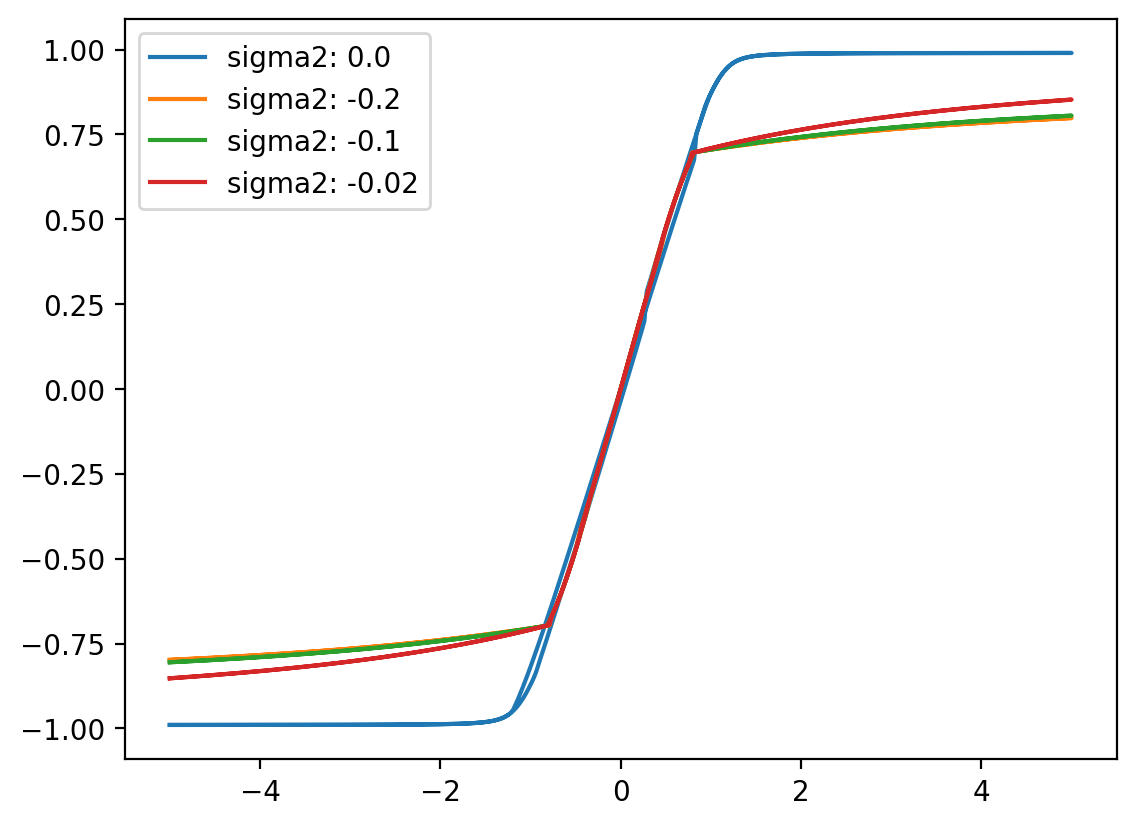

In [21]:
M_magnum = np.zeros((len(sigma2), 2*n_pts))
B_magnum = np.zeros((len(sigma2), 2*n_pts))

for i, sigma2_ in enumerate(sigma2):
        print(f"sigma2: {sigma2_}")
        M_magnum[i] = np.load(f"ref2/hysteresis_Mz_sigma2_{sigma2_}.npy")
        B_magnum[i] = np.load(f"ref2/hysteresis_Bz_sigma2_{sigma2_}.npy")
        plt.plot(B_magnum[i], M_magnum[i], label=f"sigma2: {sigma2_}")

plt.legend()

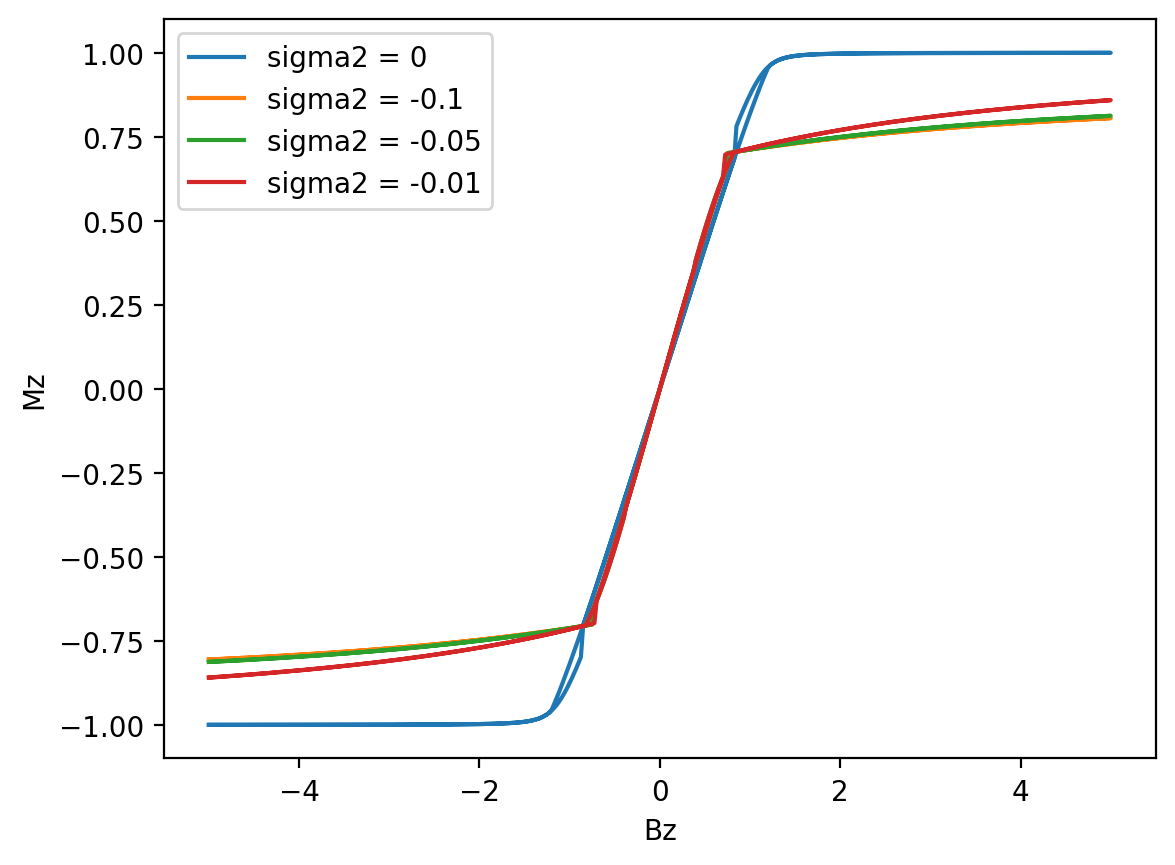

In [22]:
sigma2_oommf = [0, -0.1, -0.05, -0.01]

B_oommf = np.zeros((4, 801))
M_oommf = np.zeros((4, 801))

for i, sigma2_ in enumerate(sigma2_oommf):
    B_oommf[i] = np.load(f"ref2/oommf_hysteresis_Bz_sigma2_{sigma2_}.npy")/1000
    M_oommf[i] = np.load(f"ref2/oommf_hysteresis_mz_sigma2_{sigma2_}.npy")

    plt.plot(B_oommf[i], M_oommf[i], label = f"sigma2 = {sigma2_oommf[i]}")

plt.xlabel("Bz")
plt.ylabel("Mz")
plt.legend()

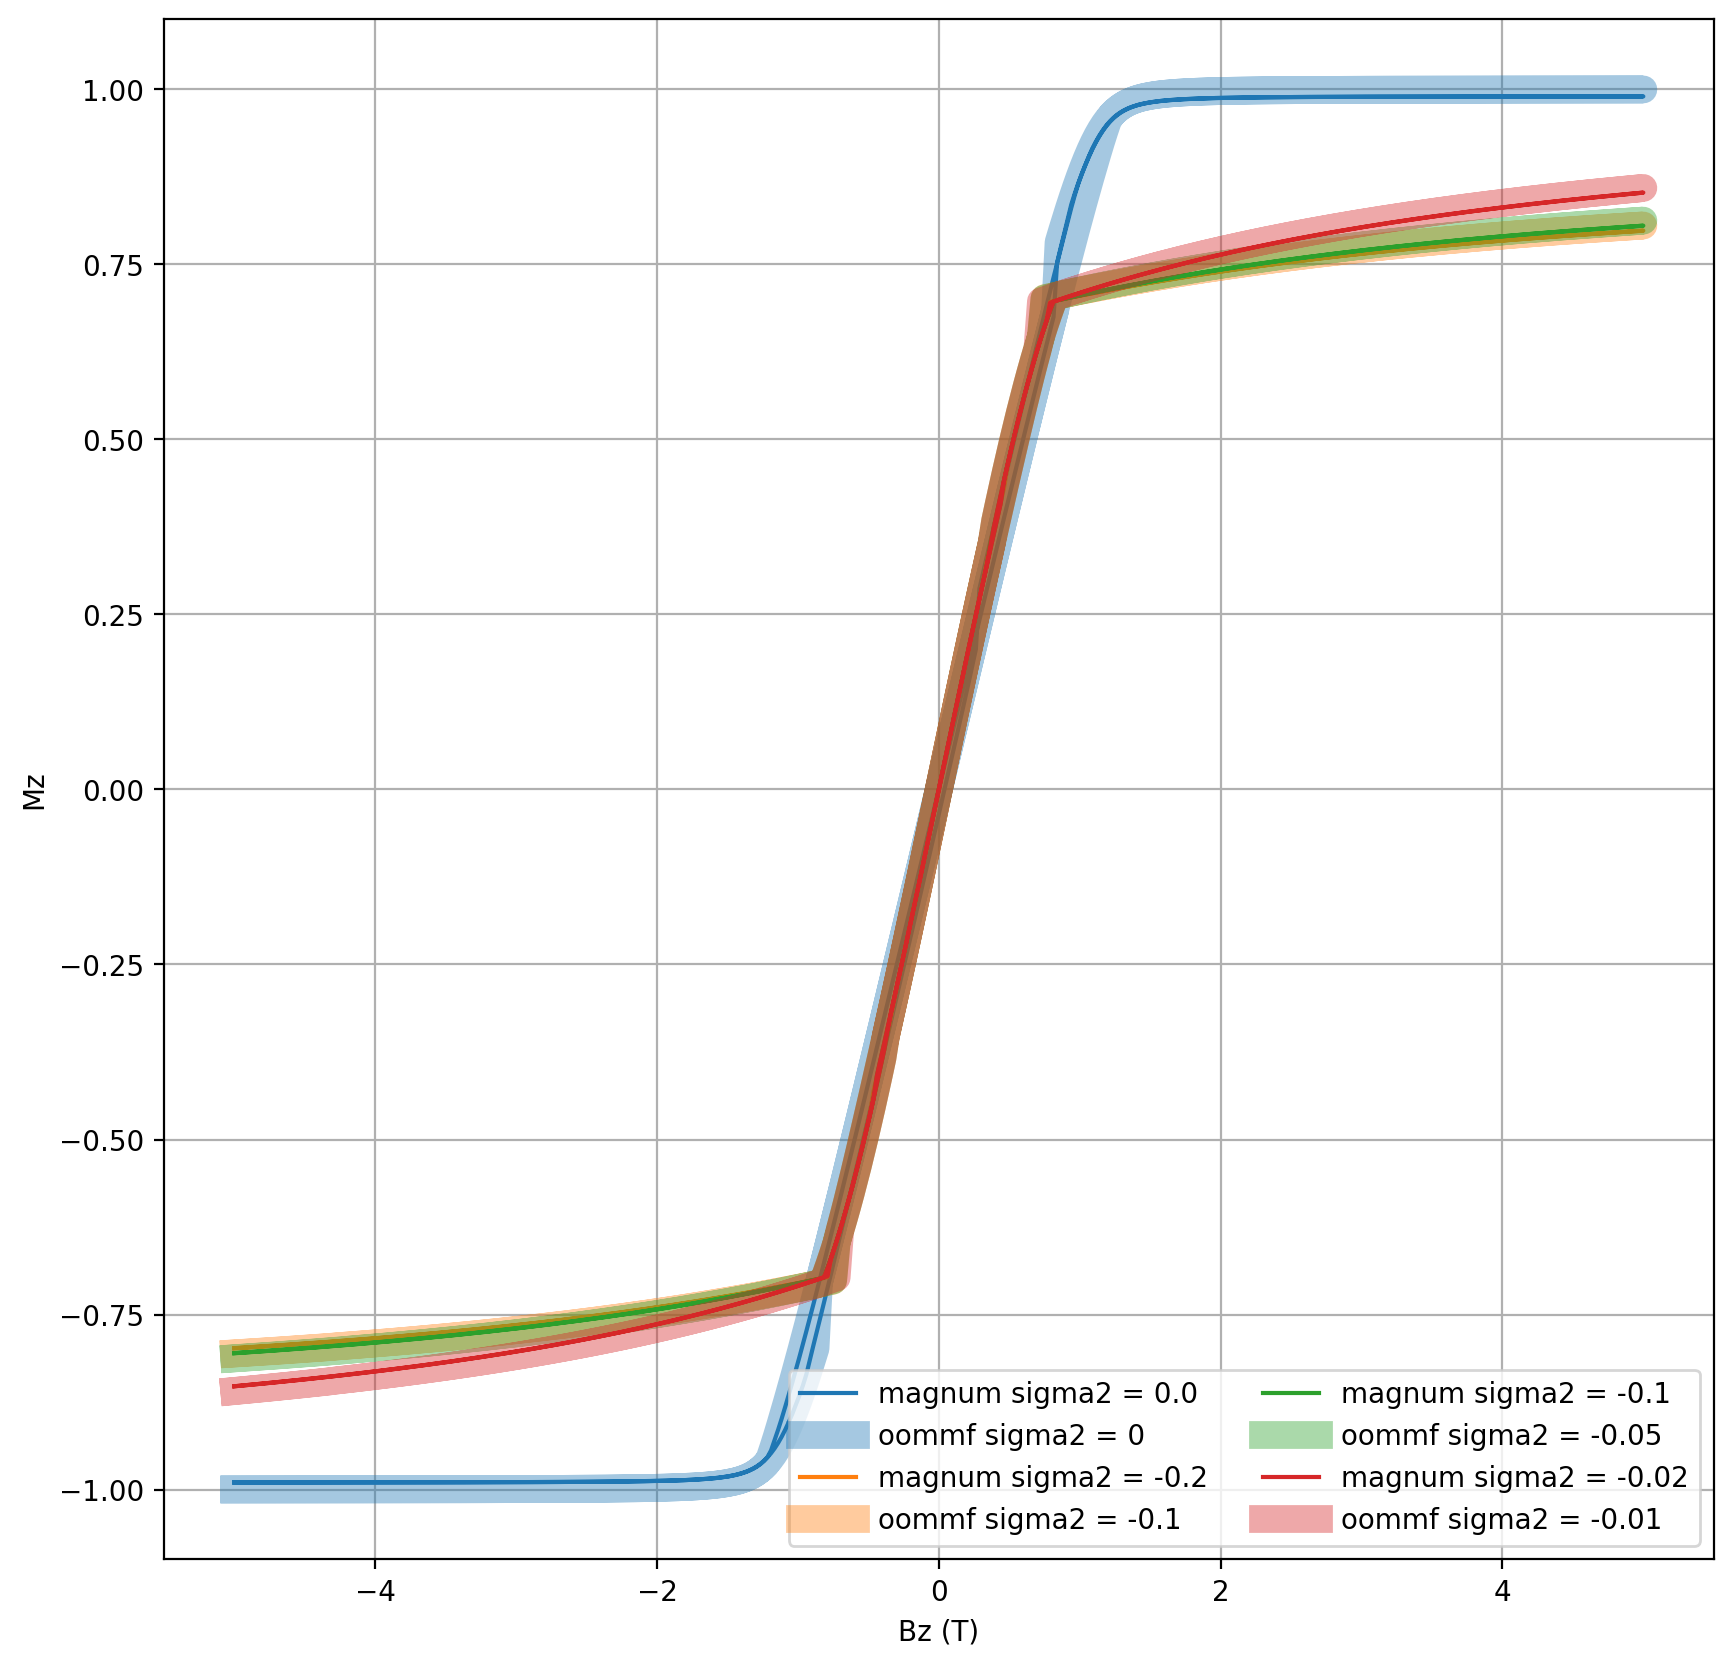

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

B_plot = np.concatenate((B_z, B_z2))

for i in range(4):
    ax.plot(B_plot, M_magnum[i], label = f"magnum sigma2 = {sigma2[i]}", color = cycle[i])
    ax.plot(B_oommf[i], M_oommf[i], alpha = 0.4,label = f"oommf sigma2 = {sigma2_oommf[i]}", color = cycle[i], linewidth = 10)

ax.set_xlabel("Bz (T)")
ax.set_ylabel("Mz")
ax.legend(ncol = 2)
ax.grid()